# India Air Quality & Crop Yield — EDA Lab

## Task 1 — First impression profile

This notebook will be completed one task at a time. The first step is to inspect both raw CSV files and understand their structure, size, completeness, and likely data-quality risks before any cleaning or modelling.

In [3]:
import csv
from collections import Counter
from datetime import datetime
from pathlib import Path

BASE = Path('/home/krypton/MCA/TRIMESTER IV/ML/ML-lab-2547246')


def profile_csv(path: Path) -> dict:
    """Return a compact profile for a raw CSV file using only the standard library."""
    with path.open(newline='', encoding='utf-8') as f:
        rows = list(csv.reader(f))

    header = rows[0]
    data = rows[1:]
    row_lengths = Counter(len(r) for r in rows)
    duplicates = Counter(tuple(r) for r in data)
    missing = Counter()

    for row in data:
        padded = row + [''] * (len(header) - len(row))
        for col, value in zip(header, padded):
            if value.strip() == '':
                missing[col] += 1

    return {
        'columns': header,
        'row_count': len(data),
        'row_length_distribution': dict(sorted(row_lengths.items())),
        'duplicate_rows': sum(c - 1 for c in duplicates.values() if c > 1),
        'missing_counts': dict(missing),
        'sample_rows': data[:3],
    }


for filename in ['city_day.csv', 'crop_production.csv']:
    profile = profile_csv(BASE / filename)
    print(f"\n=== {filename} ===")
    print('Rows:', profile['row_count'])
    print('Columns:', len(profile['columns']))
    print('Column names:', profile['columns'])
    print('Row length distribution:', profile['row_length_distribution'])
    print('Exact duplicate rows:', profile['duplicate_rows'])
    print('Missing values per column:')
    for column in profile['columns']:
        print(f"  {column}: {profile['missing_counts'].get(column, 0)}")
    print('Sample rows:')
    for row in profile['sample_rows']:
        print('  ', row)



=== city_day.csv ===
Rows: 29531
Columns: 16
Column names: ['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket']
Row length distribution: {16: 29532}
Exact duplicate rows: 0
Missing values per column:
  City: 0
  Date: 0
  PM2.5: 4598
  PM10: 11140
  NO: 3582
  NO2: 3585
  NOx: 4185
  NH3: 10328
  CO: 2059
  SO2: 3854
  O3: 4022
  Benzene: 5623
  Toluene: 8041
  Xylene: 18109
  AQI: 4681
  AQI_Bucket: 4681
Sample rows:
   ['Ahmedabad', '2015-01-01', '', '', '0.92', '18.22', '17.15', '', '0.92', '27.64', '133.36', '0.0', '0.02', '0.0', '', '']
   ['Ahmedabad', '2015-01-02', '', '', '0.97', '15.69', '16.46', '', '0.97', '24.55', '34.06', '3.68', '5.5', '3.77', '', '']
   ['Ahmedabad', '2015-01-03', '', '', '17.4', '19.3', '29.7', '', '17.4', '29.07', '30.7', '6.8', '16.4', '2.25', '', '']

=== crop_production.csv ===
Rows: 246091
Columns: 7
Column names: ['State_Name', 'District_Name', 'Crop_Year', 'Season', 

## Task 2 — Missing value treatment strategy

I treated each dataset differently because the missingness patterns are different.

### city_day.csv
- **Xylene:** drop the column. It is missing in more than 60% of rows, so imputing it would add too much guesswork.
- **AQI:** drop rows with missing values. AQI is the main outcome variable for this lab, so rows without it cannot support the later trend and distribution analysis.
- **AQI_Bucket:** no separate imputation needed once AQI-missing rows are removed, because the bucket is tied to AQI.
- **PM2.5, PM10, NO, NO2, NOx, NH3, CO, SO2, O3, Benzene, Toluene:** impute missing values with the **city-wise median**. These are continuous pollution readings, and the median is more robust than the mean for skewed environmental data. Using city-level medians also respects differences in local pollution levels.

### crop_production.csv
- **Production:** drop rows with missing values. The missing share is small, and Production is a core measurement, so inventing values would be less defensible than removing those records.

After treatment, I will verify that the null counts for the affected columns are reduced to zero or the column has been removed.

In [4]:
import pandas as pd
from pathlib import Path

BASE = Path('/home/krypton/MCA/TRIMESTER IV/ML/ML-lab-2547246')

city = pd.read_csv(BASE / 'city_day.csv')
crop = pd.read_csv(BASE / 'crop_production.csv')

print('Before treatment — city_day.csv null counts')
print(city.isna().sum().sort_values(ascending=False).to_string())
print('\nBefore treatment — crop_production.csv null counts')
print(crop.isna().sum().sort_values(ascending=False).to_string())

# --- city_day.csv ---
city.columns = city.columns.str.strip()
city['Date'] = pd.to_datetime(city['Date'], errors='coerce')

city = city.drop(columns=['Xylene'])

pollutant_cols = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene']
for col in pollutant_cols:
    city[col] = pd.to_numeric(city[col], errors='coerce')
    city[col] = city[col].fillna(city.groupby('City')[col].transform('median'))
    city[col] = city[col].fillna(city[col].median())

city = city.dropna(subset=['AQI']).copy()
city['AQI'] = pd.to_numeric(city['AQI'], errors='coerce')
city['AQI_Bucket'] = city['AQI_Bucket'].fillna('Not Available')

# --- crop_production.csv ---
crop.columns = crop.columns.str.strip()
crop['Production'] = pd.to_numeric(crop['Production'], errors='coerce')
crop = crop.dropna(subset=['Production']).copy()

print('\nAfter treatment — city_day.csv null counts')
print(city.isna().sum().sort_values(ascending=False).to_string())
print('\nAfter treatment — crop_production.csv null counts')
print(crop.isna().sum().sort_values(ascending=False).to_string())

print('\nRows retained:')
print('city_day.csv:', len(city))
print('crop_production.csv:', len(crop))
print('\nColumns retained in city_day.csv:', list(city.columns))

Before treatment — city_day.csv null counts
Xylene        18109
PM10          11140
NH3           10328
Toluene        8041
Benzene        5623
AQI            4681
AQI_Bucket     4681
PM2.5          4598
NOx            4185
O3             4022
SO2            3854
NO2            3585
NO             3582
CO             2059
Date              0
City              0

Before treatment — crop_production.csv null counts
Production       3730
District_Name       0
State_Name          0
Crop_Year           0
Season              0
Crop                0
Area                0

After treatment — city_day.csv null counts
City          0
Date          0
PM2.5         0
PM10          0
NO            0
NO2           0
NOx           0
NH3           0
CO            0
SO2           0
O3            0
Benzene       0
Toluene       0
AQI           0
AQI_Bucket    0

After treatment — crop_production.csv null counts
State_Name       0
District_Name    0
Crop_Year        0
Season           0
Crop             0


## Task 3 — State-name consistency and redundant records

A quick inspection shows an important limitation in the provided files: `city_day.csv` does **not** contain a state column at all, so there is no state-name harmonisation to perform there. The state-level file, `crop_production.csv`, does contain text-cleaning issues that would matter later when merging or grouping data.

For this task, I standardised the state-level text fields by stripping extra spaces and then checked whether that created any duplicate records. I also verified whether either dataset already contained exact duplicate rows.

In [5]:
import pandas as pd
from pathlib import Path

BASE = Path('/home/krypton/MCA/TRIMESTER IV/ML/ML-lab-2547246')
city = pd.read_csv(BASE / 'city_day.csv')
crop = pd.read_csv(BASE / 'crop_production.csv')

print('city_day.csv')
print('  state column present:', 'State' in city.columns)
print('  exact duplicate rows:', city.duplicated().sum())
print('')

print('crop_production.csv — inconsistencies found before cleaning')
for col in ['State_Name', 'District_Name', 'Season', 'Crop']:
    s = crop[col].astype(str)
    trimmed = s.str.strip()
    changed = crop.loc[s != trimmed, col]
    if len(changed) > 0:
        print(f'  {col}: {len(changed)} rows need trimming')
        print(changed.value_counts().to_string())
    else:
        print(f'  {col}: no trimming needed')

crop_clean = crop.copy()
for col in ['State_Name', 'District_Name', 'Season', 'Crop']:
    crop_clean[col] = crop_clean[col].astype(str).str.strip()

before_rows = len(crop_clean)
before_dups = crop_clean.duplicated().sum()
crop_clean = crop_clean.drop_duplicates()
after_rows = len(crop_clean)
after_dups = crop_clean.duplicated().sum()

print('\nRecord counts for crop_production.csv')
print('  before cleaning:', before_rows)
print('  exact duplicates before cleaning:', before_dups)
print('  after strip + drop_duplicates:', after_rows)
print('  exact duplicates after cleaning:', after_dups)

print('\nState names after cleaning:')
print(sorted(crop_clean['State_Name'].unique()))

city_day.csv
  state column present: False
  exact duplicate rows: 0

crop_production.csv — inconsistencies found before cleaning
  State_Name: 7283 rows need trimming
State_Name
Telangana             5649
Jammu and Kashmir     1634
  District_Name: no trimming needed
  Season: 246091 rows need trimming
Season
Kharif         95951
Rabi           66987
Whole Year     57305
Summer         14841
Winter          6058
Autumn          4949
  Crop: 1985 rows need trimming
Crop
Coconut     1985

Record counts for crop_production.csv
  before cleaning: 246091
  exact duplicates before cleaning: 0
  after strip + drop_duplicates: 246091
  exact duplicates after cleaning: 0

State names after cleaning:
['Andaman and Nicobar Islands', 'Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'Dadra and Nagar Haveli', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu and Kashmir', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meg

## Task 4 — AQI distribution shape

To answer the board's two questions, I need one view that shows where AQI values cluster and another that makes extreme values obvious. A histogram shows the overall shape, while a boxplot makes skewness and unusually high readings easy to see.

My expectation is that the distribution will be right-skewed, so I will compare the mean with the median as part of the interpretation.

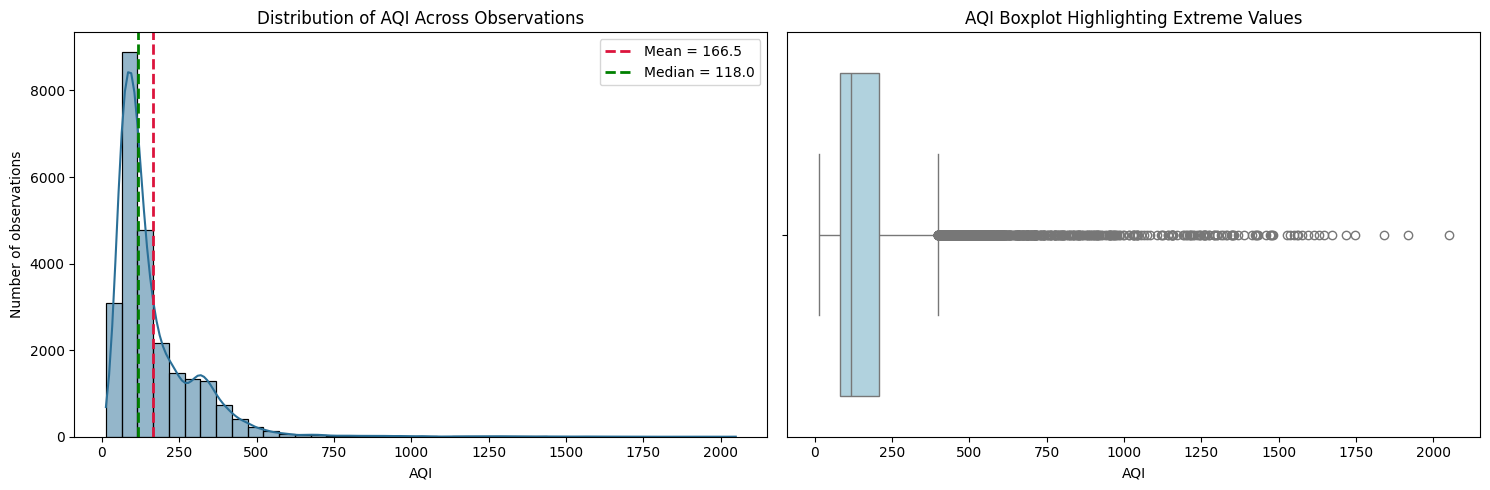

Mean AQI: 166.46
Median AQI: 118.00
Max AQI: 2049.00
95th percentile AQI: 407.00
99th percentile AQI: 661.51


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

BASE = Path('/home/krypton/MCA/TRIMESTER IV/ML/ML-lab-2547246')
city = pd.read_csv(BASE / 'city_day.csv')
city.columns = city.columns.str.strip()
city = city.drop(columns=['Xylene'])
city['AQI'] = pd.to_numeric(city['AQI'], errors='coerce')
city = city.dropna(subset=['AQI']).copy()

mean_aqi = city['AQI'].mean()
median_aqi = city['AQI'].median()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(city['AQI'], bins=40, kde=True, ax=axes[0], color='#2a6f97')
axes[0].axvline(mean_aqi, color='crimson', linestyle='--', linewidth=2, label=f'Mean = {mean_aqi:.1f}')
axes[0].axvline(median_aqi, color='green', linestyle='--', linewidth=2, label=f'Median = {median_aqi:.1f}')
axes[0].set_title('Distribution of AQI Across Observations')
axes[0].set_xlabel('AQI')
axes[0].set_ylabel('Number of observations')
axes[0].legend()

sns.boxplot(x=city['AQI'], ax=axes[1], color='#a9d6e5')
axes[1].set_title('AQI Boxplot Highlighting Extreme Values')
axes[1].set_xlabel('AQI')

plt.tight_layout()
plt.show()

print(f'Mean AQI: {mean_aqi:.2f}')
print(f'Median AQI: {median_aqi:.2f}')
print(f'Max AQI: {city["AQI"].max():.2f}')
print(f'95th percentile AQI: {city["AQI"].quantile(0.95):.2f}')
print(f'99th percentile AQI: {city["AQI"].quantile(0.99):.2f}')

### Observations
1. The AQI distribution is strongly right-skewed: the median is 118.0, while the mean is higher at 166.5. That means the average is being pulled upward by a smaller number of very polluted observations.
2. Most observations sit below about 250 AQI, but the boxplot shows a long tail of extreme values, with the maximum reaching 2049.0. So a single average does not fairly represent a typical city-day reading.

## Task 5 — Extreme AQI values

The AQI data contains very large readings in the upper tail. I will use the IQR rule to detect unusual values, then apply percentile-based capping rather than deleting records. That keeps the dataset intact while reducing the influence of implausibly extreme readings on summary statistics and models.

I will report both the number of IQR outliers and the number of values actually capped.

Detection method: IQR rule
Q1: 81.00
Q3: 208.00
IQR: 127.00
Lower fence: -109.50
Upper fence: 398.50
IQR outliers detected: 1358

Treatment method: 99th-percentile capping
Cap value: 661.51
Values capped: 249

Before treatment summary:
count    24850.000000
mean       166.463581
std        140.696585
min         13.000000
25%         81.000000
50%        118.000000
75%        208.000000
max       2049.000000

After treatment summary:
count    24850.000000
mean       163.220080
std        121.192143
min         13.000000
25%         81.000000
50%        118.000000
75%        208.000000
max        661.510000


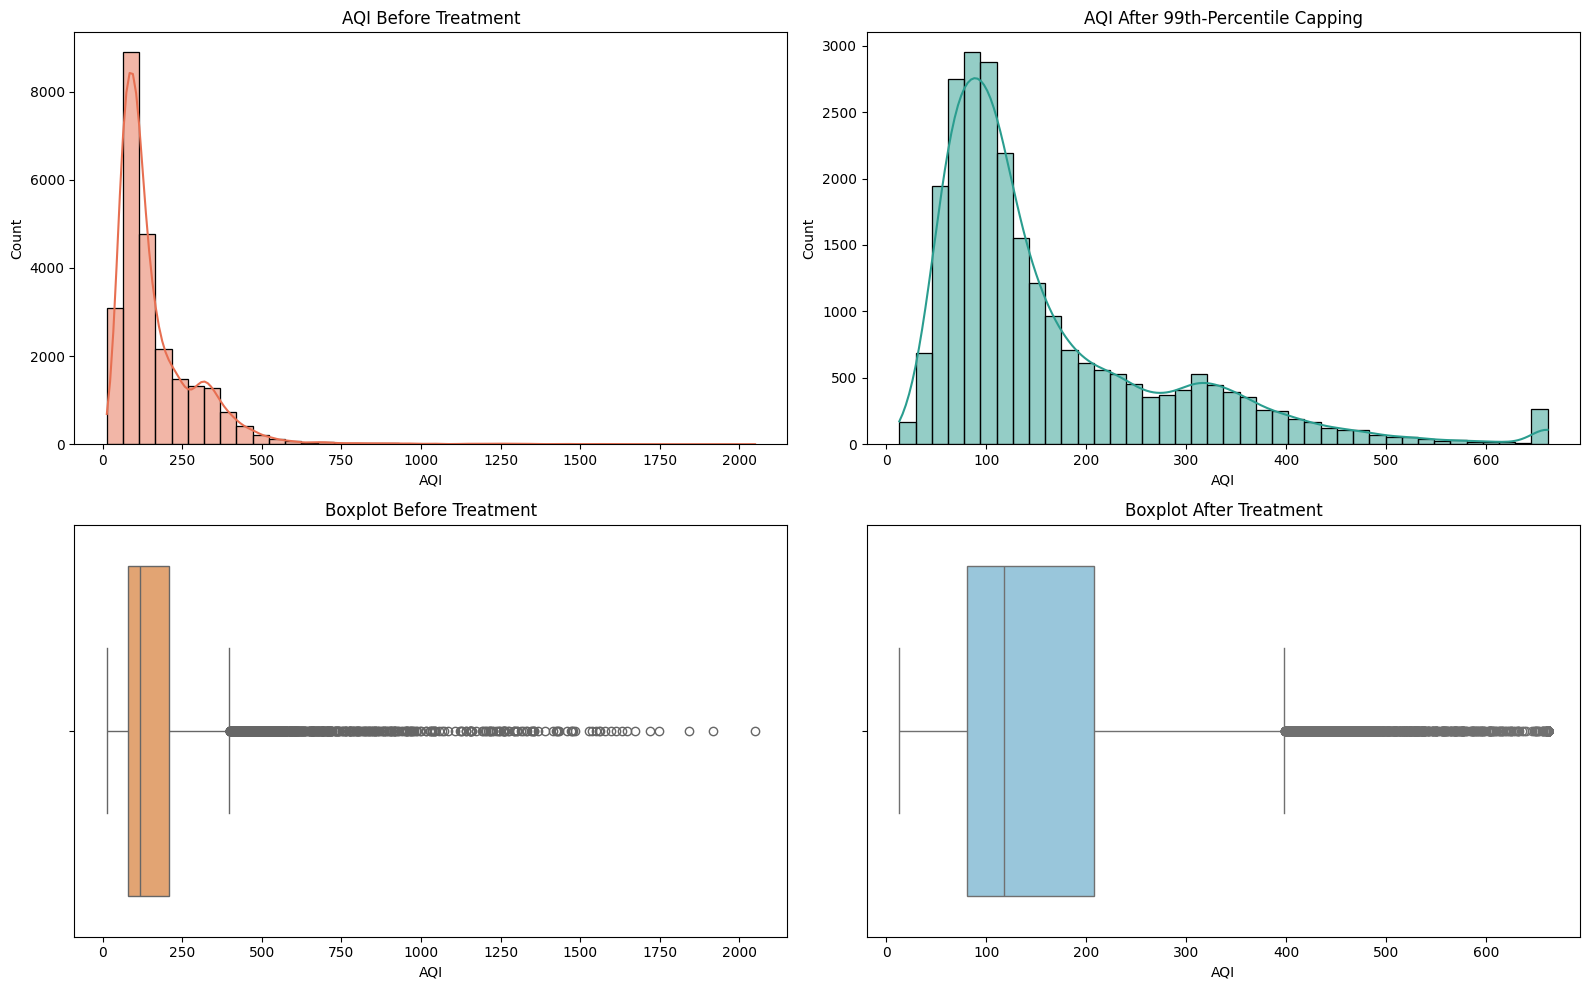

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

BASE = Path('/home/krypton/MCA/TRIMESTER IV/ML/ML-lab-2547246')
city = pd.read_csv(BASE / 'city_day.csv')
city.columns = city.columns.str.strip()
city = city.drop(columns=['Xylene'])
city['AQI'] = pd.to_numeric(city['AQI'], errors='coerce')
city = city.dropna(subset=['AQI']).copy()

q1 = city['AQI'].quantile(0.25)
q3 = city['AQI'].quantile(0.75)
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr
lower_fence = q1 - 1.5 * iqr
num_iqr_outliers = ((city['AQI'] < lower_fence) | (city['AQI'] > upper_fence)).sum()

cap_value = city['AQI'].quantile(0.99)
num_capped = (city['AQI'] > cap_value).sum()

city_clean = city.copy()
city_clean['AQI'] = city_clean['AQI'].clip(upper=cap_value)

print('Detection method: IQR rule')
print(f'Q1: {q1:.2f}')
print(f'Q3: {q3:.2f}')
print(f'IQR: {iqr:.2f}')
print(f'Lower fence: {lower_fence:.2f}')
print(f'Upper fence: {upper_fence:.2f}')
print(f'IQR outliers detected: {num_iqr_outliers}')
print('')
print('Treatment method: 99th-percentile capping')
print(f'Cap value: {cap_value:.2f}')
print(f'Values capped: {num_capped}')
print('')
print('Before treatment summary:')
print(city['AQI'].describe().to_string())
print('\nAfter treatment summary:')
print(city_clean['AQI'].describe().to_string())

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.histplot(city['AQI'], bins=40, kde=True, ax=axes[0, 0], color='#e76f51')
axes[0, 0].set_title('AQI Before Treatment')
axes[0, 0].set_xlabel('AQI')
axes[0, 0].set_ylabel('Count')

sns.histplot(city_clean['AQI'], bins=40, kde=True, ax=axes[0, 1], color='#2a9d8f')
axes[0, 1].set_title('AQI After 99th-Percentile Capping')
axes[0, 1].set_xlabel('AQI')
axes[0, 1].set_ylabel('Count')

sns.boxplot(x=city['AQI'], ax=axes[1, 0], color='#f4a261')
axes[1, 0].set_title('Boxplot Before Treatment')
axes[1, 0].set_xlabel('AQI')

sns.boxplot(x=city_clean['AQI'], ax=axes[1, 1], color='#8ecae6')
axes[1, 1].set_title('Boxplot After Treatment')
axes[1, 1].set_xlabel('AQI')

plt.tight_layout()
plt.show()

### Interpretation
1. The IQR rule flagged 1,358 unusually high AQI readings, confirming that the distribution has a heavy upper tail.
2. I capped only the top 1% of AQI values, which affected 249 records and reduced the maximum AQI from 2049.0 to 661.5. This keeps the dataset complete while preventing a small number of extreme values from dominating the summary statistics.
3. The mean fell from 166.46 to 163.22 and the standard deviation dropped from 140.70 to 121.19, showing that the treatment made the data less distorted without changing the central pattern.